# 02: Category-wise Cosine Similarity (BabyView vs THINGS)

This notebook computes category-wise cosine similarity between BabyView and THINGS **exemplar-averaged** embeddings.

- Uses `CATEGORY_SET` (`valid129` default, `valid85` optional) with `data/included_categories_{valid85|valid129}.txt`
- Reads CLIP, DINOv3, and BabyDINOv3 (BV + THINGS z-score tables) from `analysis/manuscript-2026/exemplar_set_embeddings/{valid85|valid129}/`
- Saves tables under `main_results_valid129s_04302026/results/` or `supplemental_results_valid85cats_04302026/results/`
- Plots only the fixed top/bottom 5 categories requested for visualization



In [5]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.metrics.pairwise import cosine_similarity

print("Imports loaded.")


Imports loaded.


In [6]:
# Project layout: prefer cwd under analysis/manuscript-2026/ (same as 01 / 05).
# Resolve repo root by walking up so montage precision CSV still loads if cwd is deeper
# (e.g. supplemental_results_*); a bare parents[1] from that folder points at `analysis/`, not the repo.
def _find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "annotation" / "per_file_precision_data.csv").is_file() and (p / "data").is_dir():
            return p
    return start.parents[1]


PROJECT_ROOT = _find_project_root(Path.cwd())
ANALYSIS_DIR = PROJECT_ROOT / "analysis"
DATA_DIR = PROJECT_ROOT / "data"
PREPRINT_DIR = ANALYSIS_DIR / "manuscript-2026"

# Set this once at the top of the notebook.
# Supported values: "valid129" (default) or "valid85"
CATEGORY_SET = "valid129"

CATEGORY_FILES = {
    "valid85": DATA_DIR / "included_categories_valid85.txt",
    "valid129": DATA_DIR / "included_categories_valid129.txt",
}
if CATEGORY_SET not in CATEGORY_FILES:
    raise ValueError(
        f"Unsupported CATEGORY_SET: {CATEGORY_SET!r} (expected one of {sorted(CATEGORY_FILES)})"
    )
INCLUDED_CATEGORIES_TXT = CATEGORY_FILES[CATEGORY_SET]

if CATEGORY_SET == "valid129":
    OUTPUT_RUN_ROOT = PREPRINT_DIR / "main_results_valid129s_04302026"
else:
    OUTPUT_RUN_ROOT = PREPRINT_DIR / "supplemental_results_valid85cats_04302026"

RESULTS_DIR = OUTPUT_RUN_ROOT / "results"
FIGURES_DIR = OUTPUT_RUN_ROOT / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Backward-compatible aliases used by downstream cells in this notebook.
OUTPUT_RESULTS_DIR = RESULTS_DIR
OUTPUT_FIG_DIR = FIGURES_DIR

# Embedding files from exemplar_set_embeddings/{valid85|valid129}/
EXEMPLAR_EMBED_DIR = PREPRINT_DIR / "exemplar_set_embeddings" / CATEGORY_SET
CLIP_BV_EMBEDDINGS_CSV = EXEMPLAR_EMBED_DIR / f"bv_clip_exemplar_avg_zscore_within_{CATEGORY_SET}.csv"
CLIP_THINGS_EMBEDDINGS_CSV = EXEMPLAR_EMBED_DIR / f"things_clip_exemplar_avg_zscore_within_{CATEGORY_SET}.csv"
DINO_BV_EMBEDDINGS_CSV = EXEMPLAR_EMBED_DIR / f"bv_dinov3_exemplar_avg_zscore_within_{CATEGORY_SET}.csv"
DINO_THINGS_EMBEDDINGS_CSV = EXEMPLAR_EMBED_DIR / f"things_dinov3_exemplar_avg_zscore_within_{CATEGORY_SET}.csv"
BABYDINOV3_BV_EMBEDDINGS_CSV = EXEMPLAR_EMBED_DIR / f"bv_babydinov3_exemplar_avg_zscore_within_{CATEGORY_SET}.csv"
BABYDINOV3_THINGS_EMBEDDINGS_CSV = EXEMPLAR_EMBED_DIR / f"things_babydinov3_exemplar_avg_zscore_within_{CATEGORY_SET}.csv"

THRESHOLD_TOKEN = "0.27"
FILE_SUFFIX = f"filtered-{THRESHOLD_TOKEN}_{CATEGORY_SET}"

OUTPUT_CSV_CLIP = RESULTS_DIR / f"category_wise_cosine_similarity_clip_{FILE_SUFFIX}.csv"
OUTPUT_CSV_DINO = RESULTS_DIR / f"category_wise_cosine_similarity_dinov3_{FILE_SUFFIX}.csv"
OUTPUT_CSV_BD3 = RESULTS_DIR / f"category_wise_cosine_similarity_babydinov3_{FILE_SUFFIX}.csv"
OUTPUT_CSV_ALL = RESULTS_DIR / f"category_wise_cosine_similarity_clip_dinov3_babydinov3_{FILE_SUFFIX}.csv"
OUTPUT_CSV_BOTH = OUTPUT_CSV_ALL  # back-compat alias
OUTPUT_TXT = RESULTS_DIR / f"category_wise_cosine_similarity_clip_dinov3_{FILE_SUFFIX}.txt"

print(f"[02_category_cosine] CATEGORY_SET={CATEGORY_SET!r}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Included categories txt: {INCLUDED_CATEGORIES_TXT}")
print(f"Run root: {OUTPUT_RUN_ROOT}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Figures dir: {FIGURES_DIR}")
print(f"CLIP BV embeddings: {CLIP_BV_EMBEDDINGS_CSV}")
print(f"CLIP THINGS embeddings: {CLIP_THINGS_EMBEDDINGS_CSV}")
print(f"DINOv3 BV embeddings: {DINO_BV_EMBEDDINGS_CSV}")
print(f"DINOv3 THINGS embeddings: {DINO_THINGS_EMBEDDINGS_CSV}")
print(f"BabyDINOv3 BV embeddings (z-score, notebook 06): {BABYDINOV3_BV_EMBEDDINGS_CSV}")
print(f"BabyDINOv3 THINGS embeddings (z-score): {BABYDINOV3_THINGS_EMBEDDINGS_CSV}")



[02_category_cosine] CATEGORY_SET='valid129'
Project root: /home/j7yang/babyview-projects/vss2026/object-detection
Included categories txt: /home/j7yang/babyview-projects/vss2026/object-detection/data/included_categories_valid129.txt
Run root: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026
Results dir: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/results
Figures dir: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures
CLIP BV embeddings: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/exemplar_set_embeddings/valid129/bv_clip_exemplar_avg_zscore_within_valid129.csv
CLIP THINGS embeddings: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/exemplar_set_embeddings/valid129/things_clip_exemplar_avg_zscore_within_valid129.csv
DIN

In [7]:
def load_embedding_csv(csv_path: Path):
    df = pd.read_csv(csv_path, index_col=0)
    if df.index.name is None or str(df.index.name).startswith("Unnamed"):
        if "Unnamed: 0" in df.columns:
            df = df.set_index("Unnamed: 0")

    dim_cols = [c for c in df.columns if re.match(r"dim_\\d+", str(c))]
    if not dim_cols:
        dim_cols = [c for c in df.columns if c != "category"]

    categories = [str(c).strip().lower() for c in df.index]
    embeddings = df[dim_cols].values.astype(np.float64)
    return categories, embeddings


def load_included_categories(txt_path: Path):
    with open(txt_path, "r") as f:
        return [line.strip().lower() for line in f if line.strip()]


def compute_category_metrics(bv_csv: Path, things_csv: Path, include_txt: Path):
    bv_categories, bv_embeddings = load_embedding_csv(bv_csv)
    th_categories, th_embeddings = load_embedding_csv(things_csv)
    included_categories = load_included_categories(include_txt)
    included_set = set(included_categories)

    shared_categories = sorted(set(bv_categories) & set(th_categories) & included_set)
    bv_idx = {c: i for i, c in enumerate(bv_categories)}
    th_idx = {c: i for i, c in enumerate(th_categories)}

    rows = []
    for cat in shared_categories:
        v1 = bv_embeddings[bv_idx[cat]]
        v2 = th_embeddings[th_idx[cat]]

        mask = np.isfinite(v1) & np.isfinite(v2)
        v1c = v1[mask]
        v2c = v2[mask]

        if len(v1c) >= 3:
            pearson_r, _ = pearsonr(v1c, v2c)
            spearman_r, _ = spearmanr(v1c, v2c)
            kendall_r, _ = kendalltau(v1c, v2c)
        else:
            pearson_r, spearman_r, kendall_r = np.nan, np.nan, np.nan

        if len(v1c) > 0:
            cosine_sim = cosine_similarity(v1c.reshape(1, -1), v2c.reshape(1, -1))[0, 0]
        else:
            cosine_sim = np.nan

        rows.append(
            {
                "category": cat,
                "cosine_similarity": cosine_sim,
                "pearson_r": pearson_r,
                "spearman_r": spearman_r,
                "kendall_r": kendall_r,
            }
        )

    return pd.DataFrame(rows).sort_values("cosine_similarity", ascending=False).reset_index(drop=True)


In [8]:
required_paths = [
    INCLUDED_CATEGORIES_TXT,
    CLIP_BV_EMBEDDINGS_CSV,
    CLIP_THINGS_EMBEDDINGS_CSV,
    DINO_BV_EMBEDDINGS_CSV,
    DINO_THINGS_EMBEDDINGS_CSV,
    BABYDINOV3_BV_EMBEDDINGS_CSV,
    BABYDINOV3_THINGS_EMBEDDINGS_CSV,
]
for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

# Compute cosine similarity for ALL included categories (CLIP, DINOv3, BabyDINOv3).
results_df = compute_category_metrics(
    CLIP_BV_EMBEDDINGS_CSV,
    CLIP_THINGS_EMBEDDINGS_CSV,
    INCLUDED_CATEGORIES_TXT,
)
results_df_dino = compute_category_metrics(
    DINO_BV_EMBEDDINGS_CSV,
    DINO_THINGS_EMBEDDINGS_CSV,
    INCLUDED_CATEGORIES_TXT,
)
results_df_bd3 = compute_category_metrics(
    BABYDINOV3_BV_EMBEDDINGS_CSV,
    BABYDINOV3_THINGS_EMBEDDINGS_CSV,
    INCLUDED_CATEGORIES_TXT,
)

results_df.to_csv(OUTPUT_CSV_CLIP, index=False)
results_df_dino.to_csv(OUTPUT_CSV_DINO, index=False)
results_df_bd3.to_csv(OUTPUT_CSV_BD3, index=False)

combined_df = results_df.rename(columns={"cosine_similarity": "clip_cosine_similarity"}).merge(
    results_df_dino.rename(columns={"cosine_similarity": "dinov3_cosine_similarity"}),
    on="category",
    how="outer",
).merge(
    results_df_bd3.rename(columns={"cosine_similarity": "babydinov3_cosine_similarity"}),
    on="category",
    how="outer",
)
combined_df = combined_df.sort_values("clip_cosine_similarity", ascending=False, na_position="last").reset_index(drop=True)
combined_df.to_csv(OUTPUT_CSV_ALL, index=False)

clip_vals = combined_df["clip_cosine_similarity"].to_numpy(dtype=float)
dino_vals = combined_df["dinov3_cosine_similarity"].to_numpy(dtype=float)
bd3_vals = combined_df["babydinov3_cosine_similarity"].to_numpy(dtype=float)

summary_lines = [
    "=" * 72,
    "CATEGORY-WISE COSINE SIMILARITY (BABYVIEW vs THINGS): CLIP + DINOv3 + BabyDINOv3",
    "=" * 72,
    f"CATEGORY_SET: {CATEGORY_SET}",
    f"Included categories file: {INCLUDED_CATEGORIES_TXT}",
    f"Categories analyzed: {len(combined_df)}",
    "",
    "CLIP summary:",
    f"  Mean:   {np.nanmean(clip_vals):.6f}",
    f"  Std:    {np.nanstd(clip_vals):.6f}",
    f"  Median: {np.nanmedian(clip_vals):.6f}",
    f"  Min:    {np.nanmin(clip_vals):.6f}",
    f"  Max:    {np.nanmax(clip_vals):.6f}",
    "",
    "DINOv3 summary:",
    f"  Mean:   {np.nanmean(dino_vals):.6f}",
    f"  Std:    {np.nanstd(dino_vals):.6f}",
    f"  Median: {np.nanmedian(dino_vals):.6f}",
    f"  Min:    {np.nanmin(dino_vals):.6f}",
    f"  Max:    {np.nanmax(dino_vals):.6f}",
    "",
    "BabyDINOv3 summary:",
    f"  Mean:   {np.nanmean(bd3_vals):.6f}",
    f"  Std:    {np.nanstd(bd3_vals):.6f}",
    f"  Median: {np.nanmedian(bd3_vals):.6f}",
    f"  Min:    {np.nanmin(bd3_vals):.6f}",
    f"  Max:    {np.nanmax(bd3_vals):.6f}",
]

with open(OUTPUT_TXT, "w") as f:
    f.write("\n".join(summary_lines) + "\n")

print("Computation complete.")
print(f"Saved: {OUTPUT_CSV_CLIP}")
print(f"Saved: {OUTPUT_CSV_DINO}")
print(f"Saved: {OUTPUT_CSV_BD3}")
print(f"Saved: {OUTPUT_CSV_ALL}")
print(f"Saved: {OUTPUT_TXT}")
display(combined_df.head(20))



Computation complete.
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/results/category_wise_cosine_similarity_clip_filtered-0.27_valid129.csv
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/results/category_wise_cosine_similarity_dinov3_filtered-0.27_valid129.csv
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/results/category_wise_cosine_similarity_babydinov3_filtered-0.27_valid129.csv
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/results/category_wise_cosine_similarity_clip_dinov3_babydinov3_filtered-0.27_valid129.csv
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/results/category_wise_cosine_similarity_clip_dinov3_filtered-0.2

,category,clip_cosine_similarity,pearson_r_x,spearman_r_x,kendall_r_x,dinov3_cosine_similarity,pearson_r_y,spearman_r_y,kendall_r_y,babydinov3_cosine_similarity,pearson_r,spearman_r,kendall_r
0,cat,0.801301,0.801384,0.788143,0.596074,0.489895,0.489929,0.464802,0.322869,0.513597,0.513643,0.496869,0.343296
1,cracker,0.784990,0.784908,0.775760,0.581764,0.718032,0.717889,0.696906,0.507178,0.492640,0.492627,0.485158,0.335021
2,foot,0.778272,0.777877,0.773028,0.578599,0.759989,0.760091,0.740750,0.548552,0.253934,0.253934,0.239846,0.161252
3,pizza,0.775663,0.775393,0.761348,0.564610,0.705886,0.705824,0.676681,0.487892,0.737645,0.737647,0.726507,0.531460
4,crib,0.774984,0.774636,0.756636,0.563280,0.718637,0.718776,0.692299,0.506906,0.558101,0.558105,0.542293,0.378020
5,shower,0.773565,0.771291,0.758201,0.561629,0.737960,0.738012,0.709352,0.522327,0.624407,0.624376,0.598041,0.424670
6,comb,0.757598,0.757852,0.738918,0.543619,0.658614,0.658721,0.653647,0.472043,0.469107,0.469096,0.459516,0.315421
7,shoe,0.757484,0.757761,0.752558,0.553892,0.647320,0.647332,0.629702,0.448840,0.206642,0.206677,0.178600,0.119937
8,hose,0.754353,0.755652,0.731715,0.541876,0.637396,0.637467,0.612321,0.437330,0.495112,0.495081,0.497814,0.344842
9,scissors,0.749160,0.749298,0.725151,0.534537,0.848339,0.848336,0.820069,0.634955,0.349062,0.349022,0.332953,0.225322


Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/bv_things_category_correlation_histogram_clip_dinov3_filtered-0.27_valid129.png
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/bv_things_category_correlation_histogram_clip_dinov3_filtered-0.27_valid129.pdf


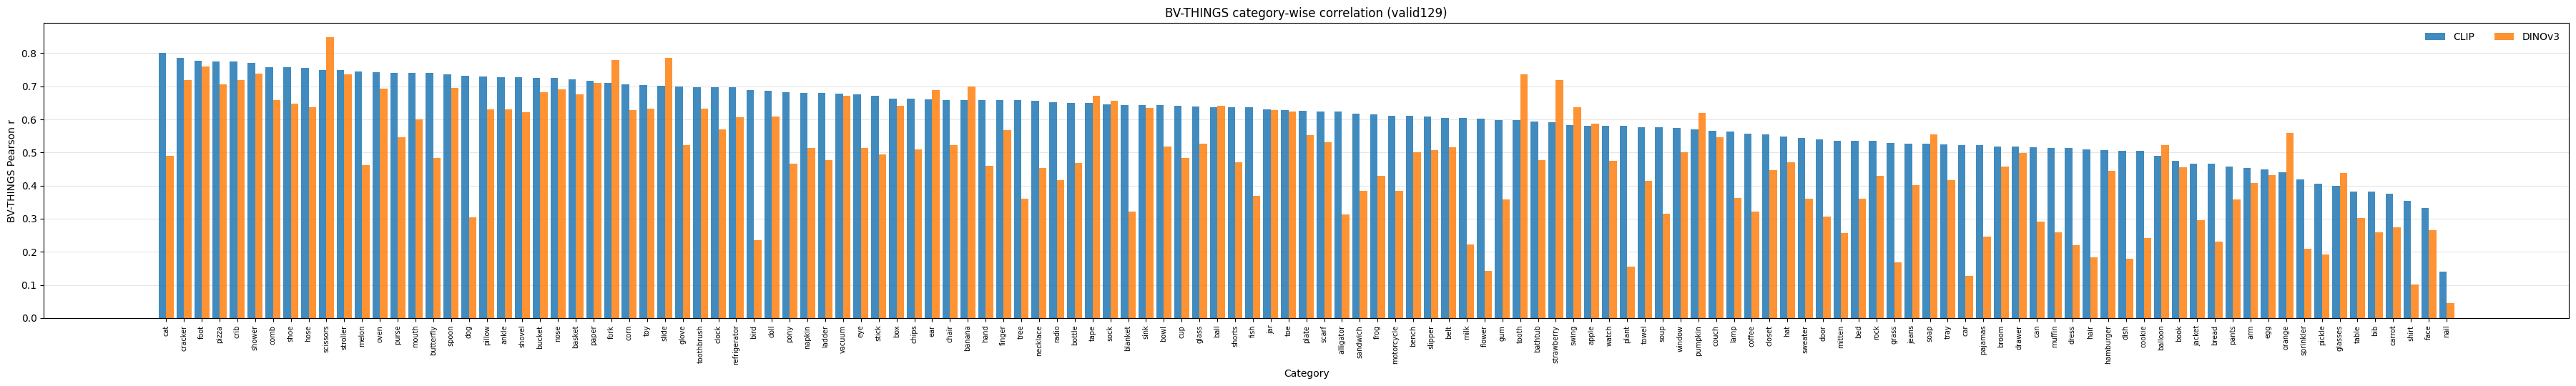

In [9]:
import matplotlib.pyplot as plt


def plot_bv_things_category_correlation_histogram(
    df,
    category_set: str,
    file_suffix: str,
    output_fig_dir: Path,
    correlation_metric: str = "pearson_r",
):
    """Save a category-labeled BV-THINGS correlation bar histogram."""
    correlation_cols = {
        "CLIP": f"{correlation_metric}_x",
        "DINOv3": f"{correlation_metric}_y",
    }
    missing_cols = [col for col in correlation_cols.values() if col not in df.columns]
    if missing_cols:
        raise KeyError(f"Missing expected correlation columns: {missing_cols}")

    corr_plot_df = (
        df[["category", *correlation_cols.values()]]
        .rename(columns={v: f"{k}_{correlation_metric}" for k, v in correlation_cols.items()})
        .dropna(subset=[f"{k}_{correlation_metric}" for k in correlation_cols], how="all")
        .sort_values(f"CLIP_{correlation_metric}", ascending=False)
        .reset_index(drop=True)
    )

    x = np.arange(len(corr_plot_df))
    bar_width = 0.42
    fig_width = max(12, 0.28 * len(corr_plot_df))
    fig, ax = plt.subplots(figsize=(fig_width, 5.5))

    ax.bar(
        x - bar_width / 2,
        corr_plot_df[f"CLIP_{correlation_metric}"],
        width=bar_width,
        label="CLIP",
        color="C0",
        alpha=0.85,
    )
    ax.bar(
        x + bar_width / 2,
        corr_plot_df[f"DINOv3_{correlation_metric}"],
        width=bar_width,
        label="DINOv3",
        color="C1",
        alpha=0.85,
    )

    ax.axhline(0, color="0.25", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(corr_plot_df["category"], rotation=90, ha="center", fontsize=7)
    ax.set_xlabel("Category")
    ax.set_ylabel("BV-THINGS Pearson r")
    ax.set_title(f"BV-THINGS category-wise correlation ({category_set})")
    ax.legend(frameon=False, ncols=2)
    ax.grid(axis="y", color="0.9", linewidth=0.8)
    ax.set_axisbelow(True)

    fig.tight_layout()

    output_fig_dir.mkdir(parents=True, exist_ok=True)
    corr_hist_png = output_fig_dir / f"bv_things_category_correlation_histogram_clip_dinov3_{file_suffix}.png"
    corr_hist_pdf = output_fig_dir / f"bv_things_category_correlation_histogram_clip_dinov3_{file_suffix}.pdf"
    fig.savefig(corr_hist_png, dpi=300, bbox_inches="tight")
    fig.savefig(corr_hist_pdf, bbox_inches="tight")

    print(f"Saved: {corr_hist_png}")
    print(f"Saved: {corr_hist_pdf}")
    return fig


fig = plot_bv_things_category_correlation_histogram(
    combined_df,
    CATEGORY_SET,
    FILE_SUFFIX,
    OUTPUT_FIG_DIR,
)
plt.show()

# Also save the 129-category version from the existing main-results table.
if CATEGORY_SET != "valid129":
    valid129_suffix = f"filtered-{THRESHOLD_TOKEN}_valid129"
    valid129_run_root = PREPRINT_DIR / "main_results_valid129s_04302026"
    valid129_csv = valid129_run_root / "results" / f"category_wise_cosine_similarity_clip_dinov3_{valid129_suffix}.csv"
    if valid129_csv.exists():
        valid129_df = pd.read_csv(valid129_csv)
        fig_valid129 = plot_bv_things_category_correlation_histogram(
            valid129_df,
            "valid129",
            valid129_suffix,
            valid129_run_root / "figures",
        )
        plt.show()
    else:
        print(f"Warning: valid129 correlation table not found: {valid129_csv}")


Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/bv_things_category_correlation_dotplot_clip_dinov3_filtered-0.27_valid129.png
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/bv_things_category_correlation_dotplot_clip_dinov3_filtered-0.27_valid129.pdf


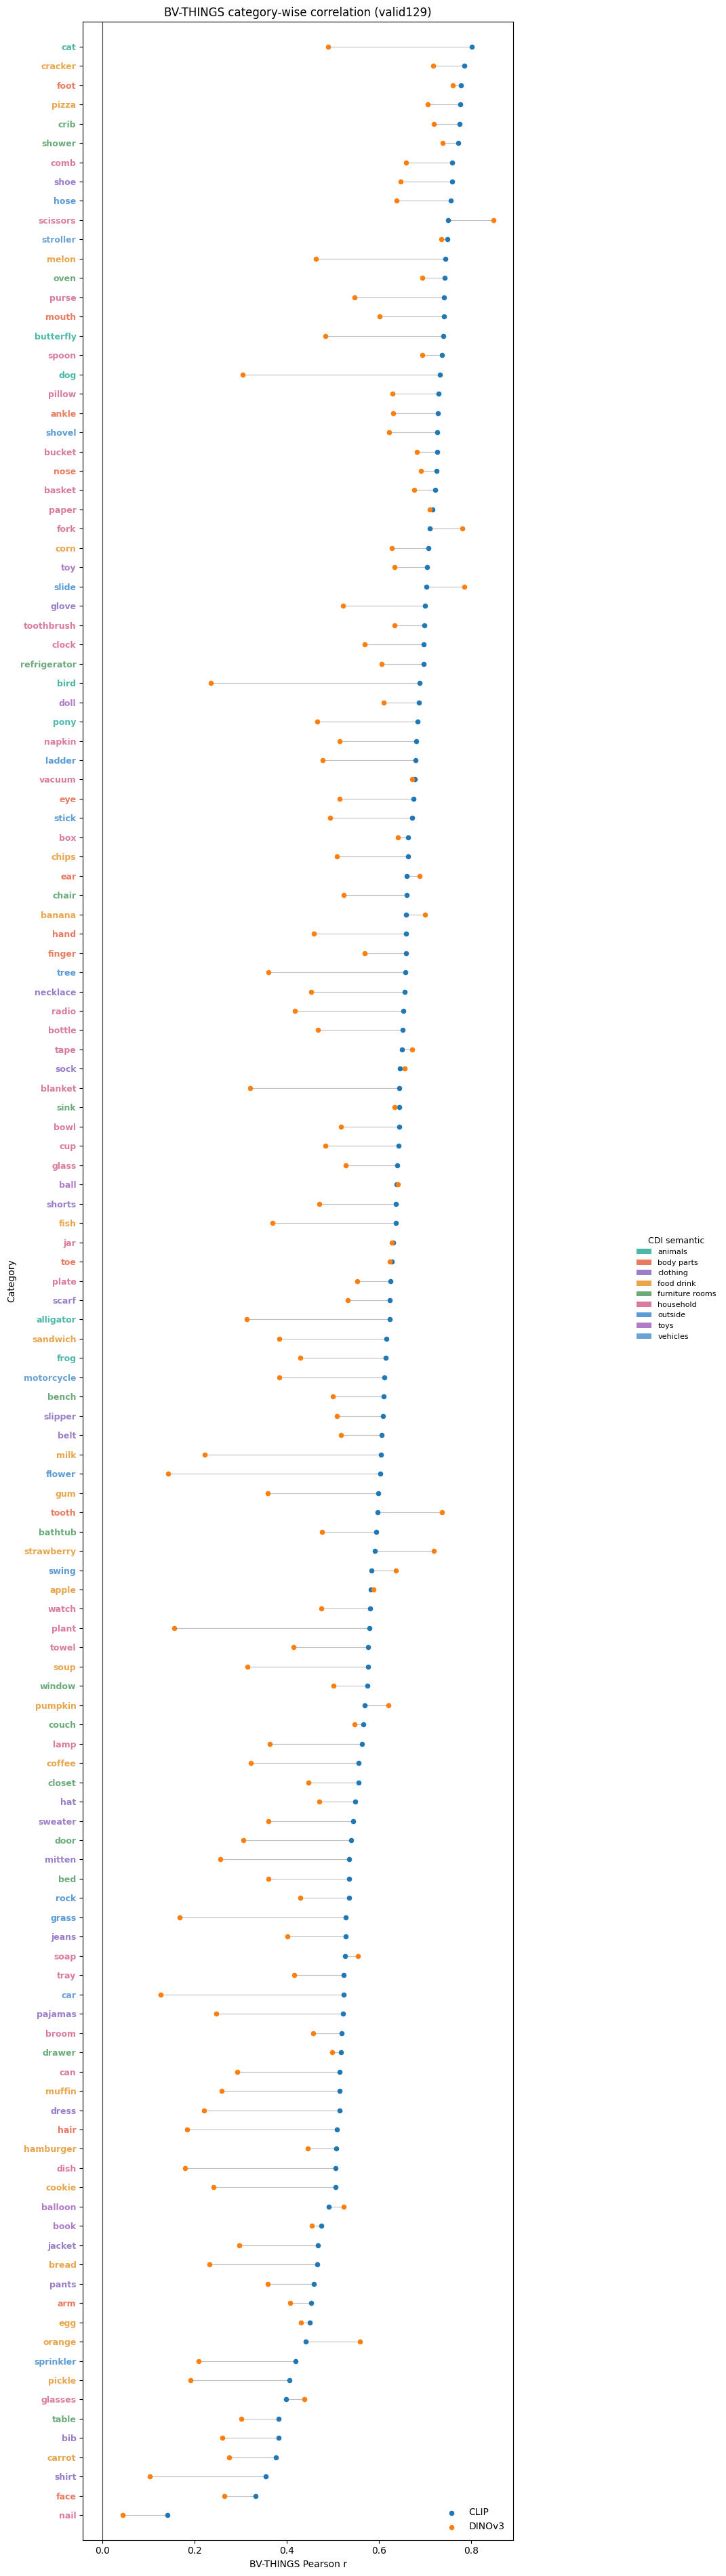

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/bv_things_category_correlation_dotplot_pages_clip_dinov3_filtered-0.27_valid129.pdf


In [10]:
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Patch

# CDI semantic domain colors / order (matches the other preprint figures).
CDI_SEMANTIC_ORDER = [
    "animals",
    "body_parts",
    "clothing",
    "food_drink",
    "furniture_rooms",
    "household",
    "outside",
    "people",
    "toys",
    "vehicles",
    "other",
]
CDI_SEMANTIC_COLORS = {
    "animals": "#4DB8A8",
    "body_parts": "#E87A5F",
    "clothing": "#9B7EC8",
    "food_drink": "#E8A54C",
    "furniture_rooms": "#6BAB7A",
    "household": "#D97B9E",
    "outside": "#5B9BD5",
    "people": "#E8C44C",
    "toys": "#B07CC8",
    "vehicles": "#6BA3D5",
    "other": "#8B9A9E",
}


def load_cdi_semantic_map_for_set(category_set: str) -> dict[str, str]:
    semantic_csv = DATA_DIR / f"long_tailed_dist_prop_included_categories_{category_set}.csv"
    if not semantic_csv.exists():
        print(f"Warning: CDI semantic map not found: {semantic_csv}")
        return {}

    semantic_df = pd.read_csv(semantic_csv)
    required = {"category", "cdi_semantic"}
    missing = required.difference(semantic_df.columns)
    if missing:
        raise ValueError(f"CDI semantic CSV missing columns: {sorted(missing)}")

    return {
        str(row["category"]).strip().lower(): str(row["cdi_semantic"]).strip().lower() or "other"
        for _, row in semantic_df[["category", "cdi_semantic"]].dropna().iterrows()
    }


def color_semantic_ticklabels(ax, categories, semantic_map, fontsize: float):
    for label, category in zip(ax.get_yticklabels(), categories):
        semantic = semantic_map.get(str(category).strip().lower(), "other")
        label.set_color(CDI_SEMANTIC_COLORS.get(semantic, CDI_SEMANTIC_COLORS["other"]))
        label.set_fontweight("bold")
        label.set_fontsize(fontsize)


def add_semantic_legend(fig, semantic_map, categories):
    used_semantics = {
        semantic_map.get(str(category).strip().lower(), "other")
        for category in categories
    }
    handles = [
        Patch(facecolor=CDI_SEMANTIC_COLORS[semantic], label=semantic.replace("_", " "))
        for semantic in CDI_SEMANTIC_ORDER
        if semantic in used_semantics
    ]
    if handles:
        fig.legend(
            handles=handles,
            title="CDI semantic",
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.01, 0.5),
            fontsize=8,
            title_fontsize=9,
        )


def plot_bv_things_category_correlation_dotplot(
    df,
    category_set: str,
    file_suffix: str,
    output_fig_dir: Path,
    correlation_metric: str = "pearson_r",
):
    """Save a more readable horizontal dot plot for category-wise correlations."""
    correlation_cols = {
        "CLIP": f"{correlation_metric}_x",
        "DINOv3": f"{correlation_metric}_y",
    }
    missing_cols = [col for col in correlation_cols.values() if col not in df.columns]
    if missing_cols:
        raise KeyError(f"Missing expected correlation columns: {missing_cols}")

    plot_df = (
        df[["category", *correlation_cols.values()]]
        .rename(columns={v: f"{k}_{correlation_metric}" for k, v in correlation_cols.items()})
        .dropna(subset=[f"{k}_{correlation_metric}" for k in correlation_cols], how="all")
        .sort_values(f"CLIP_{correlation_metric}", ascending=True)
        .reset_index(drop=True)
    )

    semantic_map = load_cdi_semantic_map_for_set(category_set)
    y = np.arange(len(plot_df))
    label_fontsize = 9
    fig_height = max(8, 0.28 * len(plot_df) + 2.0)
    fig, ax = plt.subplots(figsize=(9.25, fig_height))

    for idx, row in plot_df.iterrows():
        vals = [row[f"CLIP_{correlation_metric}"], row[f"DINOv3_{correlation_metric}"]]
        finite_vals = [v for v in vals if np.isfinite(v)]
        if len(finite_vals) == 2:
            ax.plot(finite_vals, [idx, idx], color="0.75", linewidth=0.8, zorder=1)

    ax.scatter(
        plot_df[f"CLIP_{correlation_metric}"],
        y,
        s=20,
        color="C0",
        label="CLIP",
        zorder=2,
    )
    ax.scatter(
        plot_df[f"DINOv3_{correlation_metric}"],
        y,
        s=20,
        color="C1",
        label="DINOv3",
        zorder=2,
    )

    ax.axvline(0, color="0.25", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["category"])
    color_semantic_ticklabels(ax, plot_df["category"], semantic_map, label_fontsize)
    ax.set_xlabel("BV-THINGS Pearson r")
    ax.set_ylabel("Category")
    ax.set_title(f"BV-THINGS category-wise correlation ({category_set})")
    ax.legend(frameon=False, loc="lower right")
    add_semantic_legend(fig, semantic_map, plot_df["category"])
    ax.set_axisbelow(True)
    ax.margins(y=0.01)

    fig.tight_layout(rect=[0, 0, 0.84, 1])

    output_fig_dir.mkdir(parents=True, exist_ok=True)
    dotplot_png = output_fig_dir / f"bv_things_category_correlation_dotplot_clip_dinov3_{file_suffix}.png"
    dotplot_pdf = output_fig_dir / f"bv_things_category_correlation_dotplot_clip_dinov3_{file_suffix}.pdf"
    fig.savefig(dotplot_png, dpi=300, bbox_inches="tight")
    fig.savefig(dotplot_pdf, bbox_inches="tight")

    print(f"Saved: {dotplot_png}")
    print(f"Saved: {dotplot_pdf}")
    return fig


def plot_bv_things_category_correlation_dotplot_pages(
    df,
    category_set: str,
    file_suffix: str,
    output_fig_dir: Path,
    correlation_metric: str = "pearson_r",
    categories_per_page: int = 45,
):
    """Save a paginated PDF for easier category-label reading."""
    correlation_cols = {
        "CLIP": f"{correlation_metric}_x",
        "DINOv3": f"{correlation_metric}_y",
    }
    plot_df = (
        df[["category", *correlation_cols.values()]]
        .rename(columns={v: f"{k}_{correlation_metric}" for k, v in correlation_cols.items()})
        .dropna(subset=[f"{k}_{correlation_metric}" for k in correlation_cols], how="all")
        .sort_values(f"CLIP_{correlation_metric}", ascending=False)
        .reset_index(drop=True)
    )

    output_fig_dir.mkdir(parents=True, exist_ok=True)
    pages_pdf = output_fig_dir / f"bv_things_category_correlation_dotplot_pages_clip_dinov3_{file_suffix}.pdf"
    semantic_map = load_cdi_semantic_map_for_set(category_set)

    with PdfPages(pages_pdf) as pdf:
        for start in range(0, len(plot_df), categories_per_page):
            page_df = plot_df.iloc[start : start + categories_per_page].copy()
            page_df = page_df.sort_values(f"CLIP_{correlation_metric}", ascending=True).reset_index(drop=True)
            y = np.arange(len(page_df))
            label_fontsize = 10
            fig, ax = plt.subplots(figsize=(9.25, max(7.5, 0.30 * len(page_df) + 2.0)))

            for idx, row in page_df.iterrows():
                vals = [row[f"CLIP_{correlation_metric}"], row[f"DINOv3_{correlation_metric}"]]
                finite_vals = [v for v in vals if np.isfinite(v)]
                if len(finite_vals) == 2:
                    ax.plot(finite_vals, [idx, idx], color="0.75", linewidth=0.8, zorder=1)

            ax.scatter(page_df[f"CLIP_{correlation_metric}"], y, s=24, color="C0", label="CLIP", zorder=2)
            ax.scatter(page_df[f"DINOv3_{correlation_metric}"], y, s=24, color="C1", label="DINOv3", zorder=2)
            ax.axvline(0, color="0.25", linewidth=0.8)
            ax.set_yticks(y)
            ax.set_yticklabels(page_df["category"])
            color_semantic_ticklabels(ax, page_df["category"], semantic_map, label_fontsize)
            ax.set_xlabel("BV-THINGS Pearson r")
            ax.set_ylabel("Category")
            page_num = start // categories_per_page + 1
            page_total = int(np.ceil(len(plot_df) / categories_per_page))
            ax.set_title(f"BV-THINGS category-wise correlation ({category_set}), page {page_num}/{page_total}")
            ax.legend(frameon=False, loc="lower right")
            add_semantic_legend(fig, semantic_map, page_df["category"])
            ax.set_axisbelow(True)
            fig.tight_layout(rect=[0, 0, 0.84, 1])
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    print(f"Saved: {pages_pdf}")
    return pages_pdf


fig = plot_bv_things_category_correlation_dotplot(
    combined_df,
    CATEGORY_SET,
    FILE_SUFFIX,
    OUTPUT_FIG_DIR,
)
plt.show()
plot_bv_things_category_correlation_dotplot_pages(
    combined_df,
    CATEGORY_SET,
    FILE_SUFFIX,
    OUTPUT_FIG_DIR,
)

if CATEGORY_SET != "valid129":
    valid129_suffix = f"filtered-{THRESHOLD_TOKEN}_valid129"
    valid129_run_root = PREPRINT_DIR / "main_results_valid129s_04302026"
    valid129_csv = valid129_run_root / "results" / f"category_wise_cosine_similarity_clip_dinov3_{valid129_suffix}.csv"
    if valid129_csv.exists():
        valid129_df = pd.read_csv(valid129_csv)
        fig_valid129 = plot_bv_things_category_correlation_dotplot(
            valid129_df,
            "valid129",
            valid129_suffix,
            valid129_run_root / "figures",
        )
        plt.show()
        plot_bv_things_category_correlation_dotplot_pages(
            valid129_df,
            "valid129",
            valid129_suffix,
            valid129_run_root / "figures",
        )
    else:
        print(f"Warning: valid129 correlation table not found: {valid129_csv}")


## Top/Bottom 5 Category Montage (Per Category Set)

This section plots top/bottom categories using BV crops and THINGS exemplars for the **current** `CATEGORY_SET`.

- Default behavior: choose top 5 and bottom 5 from `combined_df` for the active set (`valid129` or `valid85`), excluding **body-part** categories and **`glasses`** (see `MONTAGE_EXCLUDE_CATEGORIES` in the montage setup cell).
- BabyView thumbnails: when `CATEGORY_SET == "valid85"`, stems used in the 129-category sampled bucket montage CSV are skipped when possible (`BV_EXCLUDE_STEMS_USED_IN_129_MONTAGE`). With `BV_MONTAGE_STRICT_PRECISION = True`, only `per_file_precision_data.csv` rows above `PRECISION_THRESHOLD` are used. If **no** such rows remain after exclusion (the CSV often annotates only a thin slice, heavily overlapping the bucket sample), the notebook **retries including bucket stems** so the row is not empty—console prints a `Note:` when that happens. Set `BV_MONTAGE_STRICT_PRECISION = False` only if you prefer a full grid filled with unannotated/sub-threshold on-disk crops.
- Optional override: provide explicit category lists per set if you want fixed publication categories (exclusions still apply).

The row labels include CLIP, DINOv3 (`bv_dinov3`), and BabyDINOv3 cosine similarity values (computed over all included categories).



In [11]:
from typing import Dict, List, Optional, Set

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image

# Paths for montage inputs.
CROPPED_DIR = Path("/data2/dataset/babyview/868_hours/outputs/yoloe_cdi_all_cropped_by_class")
THINGS_IMAGES_DIR = Path("/ccn2/dataset/babyview/outputs_20250312/things_bv_overlapping_categories_corrected")
# Canonical human precision reference for BV montage crops (repo-relative).
PRECISION_CSV = PROJECT_ROOT / "annotation" / "per_file_precision_data.csv"
PRECISION_THRESHOLD = 0.6

# BV montage: only plot crops explicitly present in PRECISION_CSV and strictly above PRECISION_THRESHOLD.
# If False: after using all qualifying crops, leftover grid slots pull unannotated / sub-threshold on-disk crops (fills the grid but violates the headline threshold).
BV_MONTAGE_STRICT_PRECISION = True

# BV crops in this notebook previously used the same rule for valid129 vs valid85 (sorted filenames, first N),
# so overlapping categories typically looked identical. When True and CATEGORY_SET is valid85, BabyView thumbnails
# skip any crop stem present in the 129-category montage / bucket CSV (same source as sampled_object_crops_..._montages).
BV_129_BUCKET_CSV = (
    PROJECT_ROOT
    / "annotation"
    / "sampled_object_crops_100_bucket_assignments_100ex_8subj_per_video_cap_babyview_only.csv"
)
BV_EXCLUDE_STEMS_USED_IN_129_MONTAGE = CATEGORY_SET == "valid85"

if not PRECISION_CSV.is_file():
    print(f"Warning: BV precision reference not found: {PRECISION_CSV.resolve()}")

# Top/bottom selection for montage rows.
# If MANUAL_TOP_BOTTOM_BY_SET[CATEGORY_SET] is None, pick top/bottom from combined_df.
MANUAL_TOP_BOTTOM_BY_SET = {
    "valid129": None,
    "valid85": None,
    # Example manual override format:
    # "valid85": {
    #     "top": ["cat", "cracker", "crib", "shower", "book"],
    #     "bottom": ["dish", "table", "shirt", "glass", "purse"],
    # },
}
N_TOP = 5
N_BOTTOM = 5

# Montage exclusions (auto top/bottom and manual overrides).
MONTAGE_EXCLUDE_CATEGORIES = frozenset(
    {
        "glasses",
        # Body-part categories present in overlap / inclusion lists (not exhaustive globally).
        "ankle",
        "arm",
        "ear",
        "eye",
        "face",
        "finger",
        "foot",
        "hair",
        "hand",
        "mouth",
        "nose",
        "toe",
        "tooth",
    }
)


def filter_montage_categories(categories: list[str]) -> tuple[list[str], list[str]]:
    """Drop excluded categories; return (kept, dropped)."""
    out: list[str] = []
    dropped: list[str] = []
    for c in categories:
        key = str(c).strip().lower()
        if key in MONTAGE_EXCLUDE_CATEGORIES:
            dropped.append(key)
        else:
            out.append(key)
    return out, dropped


def get_top_bottom_categories_for_set(df: pd.DataFrame, category_set: str, n_top: int = 5, n_bottom: int = 5):
    manual = MANUAL_TOP_BOTTOM_BY_SET.get(category_set)
    if manual is not None:
        top_raw = [str(c).strip().lower() for c in manual.get("top", [])]
        bottom_raw = [str(c).strip().lower() for c in manual.get("bottom", [])]
        top_cats, dt = filter_montage_categories(top_raw)
        bottom_cats, db = filter_montage_categories(bottom_raw)
        if dt or db:
            print(f"Excluded from manual montage lists: {sorted(set(dt + db))}")
        return top_cats[:n_top], bottom_cats[:n_bottom]

    ranked = (
        df[["category", "clip_cosine_similarity"]]
        .copy()
        .dropna(subset=["clip_cosine_similarity"])
        .assign(category=lambda x: x["category"].astype(str).str.strip().str.lower())
        .loc[lambda x: ~x["category"].isin(MONTAGE_EXCLUDE_CATEGORIES)]
        .sort_values("clip_cosine_similarity", ascending=False)
        .drop_duplicates(subset=["category"], keep="first")
        .reset_index(drop=True)
    )
    top_cats = ranked.head(n_top)["category"].tolist()
    bottom_cats = ranked.tail(n_bottom)["category"].tolist()
    return top_cats, bottom_cats


TOP_CATEGORIES, BOTTOM_CATEGORIES = get_top_bottom_categories_for_set(
    combined_df,
    CATEGORY_SET,
    n_top=N_TOP,
    n_bottom=N_BOTTOM,
)
PLOT_CATEGORIES = TOP_CATEGORIES + BOTTOM_CATEGORIES

print(f"Montage categories for {CATEGORY_SET}: top={TOP_CATEGORIES}, bottom={BOTTOM_CATEGORIES}")

N_CROPS_PER_SIDE = 10
CELL_SIZE = (80, 80)
N_COLS = 5


def get_category_dir(root_dir: Path, category: str) -> Path:
    category = category.strip().lower()
    direct = root_dir / category
    if direct.exists() and direct.is_dir():
        return direct
    for p in root_dir.iterdir():
        if p.is_dir() and p.name.strip().lower() == category:
            return p
    return root_dir / category


def load_precision_lookup(precision_csv: Path):
    if not precision_csv.exists():
        return {}
    df = pd.read_csv(precision_csv)
    df["filename"] = df["filename"].astype(str).str.strip()
    df["precision"] = pd.to_numeric(df["precision"], errors="coerce")
    return dict(zip(df["filename"], df["precision"]))


def load_bv_stems_used_in_bucket_csv(bucket_csv: Path) -> Dict[str, Set[str]]:
    """Maps category_lower -> stem set from regular BabyView crops in bucket assignment CSV."""
    if not bucket_csv.exists():
        return {}
    df = pd.read_csv(bucket_csv, usecols=["category", "stem", "trial_type"])
    df = df[df["trial_type"].astype(str) == "regular"]
    df["category"] = df["category"].astype(str).str.strip().str.lower()
    df["stem"] = df["stem"].astype(str)
    out: Dict[str, Set[str]] = {}
    for r in df.itertuples(index=False):
        out.setdefault(r.category, set()).add(r.stem)
    return out


def get_image_paths(
    root_dir: Path,
    category: str,
    n: int,
    precision_lookup=None,
    precision_threshold=None,
    exclude_stems: Optional[Set[str]] = None,
):
    """Pick up to n paths. Optional stem exclusion first. With precision CSV: only qualifying rows (+ optional fill)."""
    if not root_dir.exists():
        return []
    cat_dir = get_category_dir(root_dir, category)
    if not cat_dir.exists():
        return []
    paths = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        paths.extend(cat_dir.glob(ext))

    paths = sorted(paths, key=lambda p: p.name)
    cat_key = category.strip().lower()
    pool = paths
    if exclude_stems:
        pool = [p for p in paths if p.stem not in exclude_stems]

    if not pool:
        return []

    if precision_lookup is None or precision_threshold is None:
        return pool[:n]

    hi: List[tuple[float, Path]] = []
    unannotated: List[Path] = []
    low: List[Path] = []
    for p in pool:
        rel_key = f"{cat_key}/{p.name}"
        if rel_key not in precision_lookup:
            unannotated.append(p)
            continue
        precision = precision_lookup[rel_key]
        if pd.notna(precision) and float(precision) > precision_threshold:
            hi.append((float(precision), p))
        else:
            low.append(p)

    hi.sort(key=lambda x: (-x[0], x[1].name))
    ordered_hi = [p for _, p in hi]

    if BV_MONTAGE_STRICT_PRECISION:
        return ordered_hi[:n]

    ordered = ordered_hi + unannotated + low
    return ordered[:n]


def make_montage(paths, cell_size=(80, 80), n_cols=5):
    if not paths:
        return None
    n_rows = int(np.ceil(len(paths) / n_cols))
    out = Image.new("RGB", (n_cols * cell_size[0], n_rows * cell_size[1]), (240, 240, 240))
    for i, p in enumerate(paths):
        try:
            img = Image.open(p).convert("RGB")
            if img.size != cell_size:
                img = img.resize(cell_size, Image.Resampling.LANCZOS)
            r, c = divmod(i, n_cols)
            out.paste(img, (c * cell_size[0], r * cell_size[1]))
        except Exception:
            pass
    return out


def build_side_by_side_figure_both(rows, title):
    n_rows = len(rows)
    fig = plt.figure(figsize=(10, 2.2 * n_rows + 1.0))
    gs = GridSpec(n_rows + 1, 2, figure=fig, height_ratios=[1.0] * n_rows + [0.45], hspace=0.28, wspace=0.05, top=0.93, bottom=0.06)

    precision_lookup = load_precision_lookup(PRECISION_CSV)
    bv_stems_exclude_by_cat: Optional[Dict[str, Set[str]]] = None
    if BV_EXCLUDE_STEMS_USED_IN_129_MONTAGE:
        bv_stems_exclude_by_cat = load_bv_stems_used_in_bucket_csv(BV_129_BUCKET_CSV)
        print(
            f"BV thumbnails: excluding stems appearing in {BV_129_BUCKET_CSV.name} "
            f"({sum(len(v) for v in bv_stems_exclude_by_cat.values())} total category-stems)"
        )

    for i, row in enumerate(rows):
        cat = row["category"]
        clip_sim = row["clip_cosine"]
        dino_sim = row["dinov3_cosine"]
        exclude = (
            bv_stems_exclude_by_cat.get(str(cat).strip().lower(), set())
            if bv_stems_exclude_by_cat is not None
            else None
        )

        bv_paths = get_image_paths(
            CROPPED_DIR,
            cat,
            N_CROPS_PER_SIDE,
            precision_lookup=precision_lookup,
            precision_threshold=PRECISION_THRESHOLD,
            exclude_stems=exclude,
        )
        if (
            len(bv_paths) == 0
            and exclude
            and BV_EXCLUDE_STEMS_USED_IN_129_MONTAGE
            and BV_MONTAGE_STRICT_PRECISION
        ):
            bv_paths = get_image_paths(
                CROPPED_DIR,
                cat,
                N_CROPS_PER_SIDE,
                precision_lookup=precision_lookup,
                precision_threshold=PRECISION_THRESHOLD,
                exclude_stems=None,
            )
            if len(bv_paths) > 0:
                print(
                    f"Note: BV {cat!r}: no strict-precision crops left after bucket-stem exclusion; "
                    f"retrying including bucket stems (precision > {PRECISION_THRESHOLD})."
                )
        if len(bv_paths) == 0:
            print(
                f"Warning: no BV crops for montage row {cat!r} "
                "(missing crop folder, or no per_file precision rows above threshold)."
            )
        elif len(bv_paths) < N_CROPS_PER_SIDE and BV_MONTAGE_STRICT_PRECISION:
            print(
                "Note: BV montage "
                + f"{cat!r} uses {len(bv_paths)}/{N_CROPS_PER_SIDE} crops"
                + " (strict per_file precision; no sub-threshold fill)"
            )
        th_paths = get_image_paths(THINGS_IMAGES_DIR, cat, N_CROPS_PER_SIDE)

        ax_bv = fig.add_subplot(gs[i, 0])
        ax_th = fig.add_subplot(gs[i, 1])

        mont_bv = make_montage(bv_paths, CELL_SIZE, N_COLS)
        if mont_bv is not None:
            ax_bv.imshow(np.array(mont_bv))
        ax_bv.axis("off")
        ax_bv.set_title(f"{cat}, cos_CLIP={clip_sim:.2f}, cos_DINOv3={dino_sim:.2f}", fontsize=9)

        mont_th = make_montage(th_paths, CELL_SIZE, N_COLS)
        if mont_th is not None:
            ax_th.imshow(np.array(mont_th))
        ax_th.axis("off")

    fig.text(0.25, 0.94, "BV", fontsize=10, ha="center")
    fig.text(0.75, 0.94, "THINGS", fontsize=10, ha="center")

    ax_hist = fig.add_subplot(gs[n_rows, :])
    clip_vals = combined_df["clip_cosine_similarity"].to_numpy(dtype=float)
    dino_vals = combined_df["dinov3_cosine_similarity"].to_numpy(dtype=float)
    clip_vals = clip_vals[np.isfinite(clip_vals)]
    dino_vals = dino_vals[np.isfinite(dino_vals)]

    all_vals = np.concatenate([clip_vals, dino_vals]) if len(clip_vals) and len(dino_vals) else (clip_vals if len(clip_vals) else dino_vals)
    if len(all_vals):
        bins = np.linspace(all_vals.min(), all_vals.max(), 21)
        if len(clip_vals):
            ax_hist.hist(clip_vals, bins=bins, color="C0", alpha=0.6, edgecolor="white", label=f"CLIP (n={len(clip_vals)})")
        if len(dino_vals):
            ax_hist.hist(dino_vals, bins=bins, color="C1", alpha=0.6, edgecolor="white", label=f"DINOv3 (n={len(dino_vals)})")
        ax_hist.legend(loc="upper right", fontsize=8)

    ax_hist.set_xlabel("Cosine similarity")
    ax_hist.set_ylabel("Count")
    ax_hist.set_title(f"Cosine similarity distribution ({CATEGORY_SET})")

    fig.suptitle(title, fontsize=12, y=0.965)
    return fig


if not CROPPED_DIR.exists():
    print(f"Warning: BV crop directory not found: {CROPPED_DIR}")
if not THINGS_IMAGES_DIR.exists():
    print(f"Warning: THINGS image directory not found: {THINGS_IMAGES_DIR}")



Montage categories for valid129: top=['cat', 'cracker', 'pizza', 'crib', 'shower'], bottom=['table', 'bib', 'carrot', 'shirt', 'nail']


In [12]:
# Build rows for the selected top/bottom categories for this CATEGORY_SET.
clip_map = {
    row["category"].strip().lower(): float(row["clip_cosine_similarity"])
    for _, row in combined_df.iterrows()
}
dino_map = {
    row["category"].strip().lower(): float(row["dinov3_cosine_similarity"])
    for _, row in combined_df.iterrows()
}

available = set(combined_df["category"].astype(str).str.lower().tolist())
missing = [c for c in PLOT_CATEGORIES if c.lower() not in available]
if missing:
    print(f"Warning: categories not found in combined_df: {missing}")

rows_fixed_both = []
for cat in PLOT_CATEGORIES:
    key = cat.strip().lower()
    rows_fixed_both.append(
        {
            "category": cat,
            "clip_cosine": clip_map.get(key, np.nan),
            "dinov3_cosine": dino_map.get(key, np.nan),
        }
    )

display(pd.DataFrame(rows_fixed_both))



,category,clip_cosine,dinov3_cosine
0,cat,0.801301,0.489895
1,cracker,0.784990,0.718032
2,pizza,0.775663,0.705886
3,crib,0.774984,0.718637
4,shower,0.773565,0.737960
5,table,0.386704,0.301530
6,bib,0.381633,0.260002
7,carrot,0.375854,0.274361
8,shirt,0.354899,0.101266
9,nail,0.141266,0.044295


Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/category_wise_cosine_montage_topbottom_clip_dinov3_filtered-0.27_valid129.png
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/main_results_valid129s_04302026/figures/category_wise_cosine_montage_topbottom_clip_dinov3_filtered-0.27_valid129.pdf


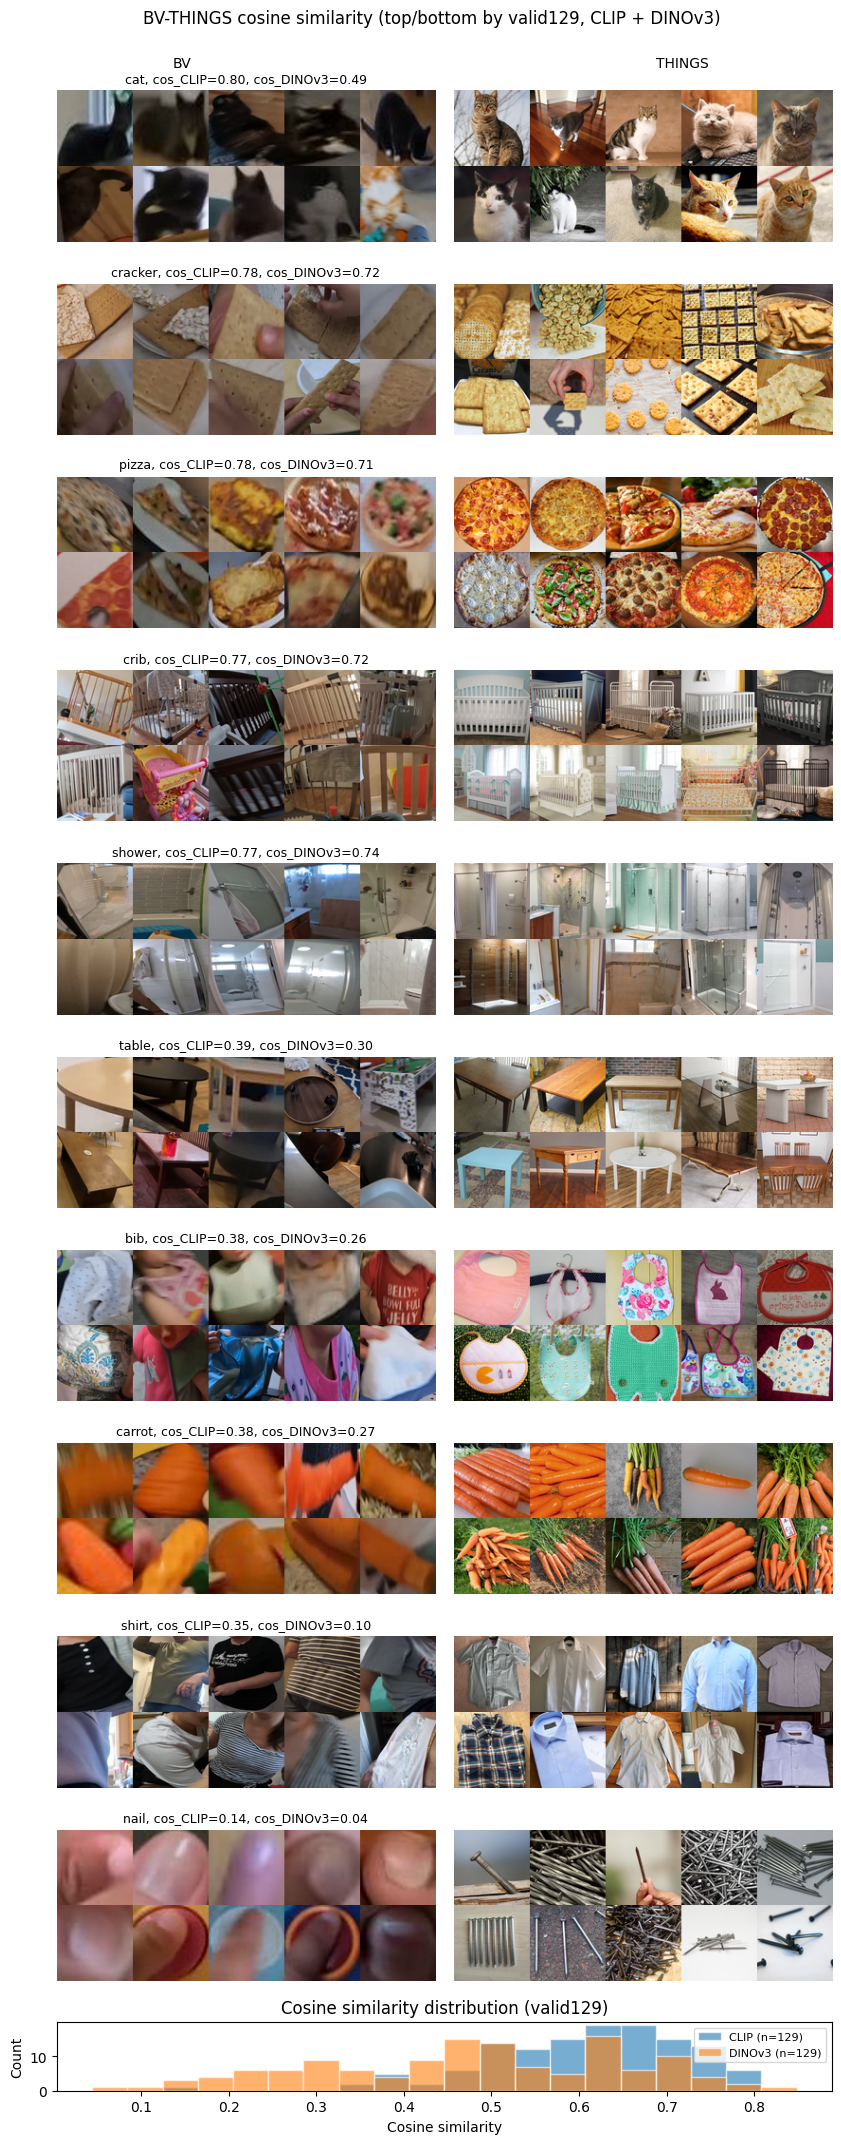

In [13]:
# Save the set-specific top/bottom montage (default: top 5 + bottom 5) with CLIP and DINOv3 values.
fig_fixed_both = build_side_by_side_figure_both(
    rows_fixed_both,
    f"BV-THINGS cosine similarity (top/bottom by {CATEGORY_SET}, CLIP + DINOv3)",
)

fixed_both_png = OUTPUT_FIG_DIR / f"category_wise_cosine_montage_topbottom_clip_dinov3_{FILE_SUFFIX}.png"
fixed_both_pdf = OUTPUT_FIG_DIR / f"category_wise_cosine_montage_topbottom_clip_dinov3_{FILE_SUFFIX}.pdf"

fig_fixed_both.savefig(fixed_both_png, dpi=150, bbox_inches="tight")
fig_fixed_both.savefig(fixed_both_pdf, bbox_inches="tight")

print(f"Saved: {fixed_both_png}")
print(f"Saved: {fixed_both_pdf}")

plt.show()

